In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp
import joblib
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE
from concurrent.futures import ThreadPoolExecutor

# Function to preprocess a chunk of the data
def preprocess_chunk(df_chunk):
    df_chunk['trans_date_trans_time'] = pd.to_datetime(df_chunk['trans_date_trans_time'])
    df_chunk['trans_hour'] = df_chunk['trans_date_trans_time'].dt.hour
    df_chunk['trans_month'] = df_chunk['trans_date_trans_time'].dt.month 
    df_chunk['trans_dayofweek'] = df_chunk['trans_date_trans_time'].dt.day_name()

    df_chunk['transaction_time'] = pd.to_datetime(df_chunk['unix_time'], unit='s')
    df_chunk = df_chunk.sort_values(by=['cc_num', 'transaction_time'])
    df_chunk['unix_time_prev_trans'] = df_chunk.groupby(by=['cc_num'])['unix_time'].shift(1)
    df_chunk = df_chunk.assign(unix_time_prev_trans=df_chunk['unix_time_prev_trans'].fillna(df_chunk['unix_time'] - 86400))
    df_chunk['timedelta_last_trans'] = (df_chunk['unix_time'] - df_chunk['unix_time_prev_trans']) // 60

    df_chunk['dob'] = pd.to_datetime(df_chunk['dob'])
    df_chunk['cust_age'] = (df_chunk['trans_date_trans_time'] - df_chunk['dob']).dt.days // 365

    return df_chunk

# Function to drop columns
def drop_columns(df):
    drop_cols = [
        'Unnamed: 0', 'street', 'zip', 'first', 'last', 'trans_num', 'trans_date_trans_time',
        'transaction_time', 'unix_time', 'unix_time_prev_trans', 'lat', 'long',
        'merch_lat', 'merch_long', 'dob'
    ]
    return df.drop(columns=drop_cols)

# Load the raw dataset in chunks and preprocess in parallel
df_chunks = pd.read_csv('../../data/raw/Fraudtrain.csv', chunksize=50000)

with ThreadPoolExecutor() as executor:
    df_processed = pd.concat(executor.map(preprocess_chunk, df_chunks))

# Drop unnecessary columns
df_processed = drop_columns(df_processed)

# Split the data into X and y
X = df_processed.drop(columns=["is_fraud"])
y = df_processed["is_fraud"]

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# One-Hot Encoding for all categorical features
ohe = OneHotEncoder(sparse_output=True, drop='first', handle_unknown='ignore')

# Identify categorical columns for encoding
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Fit and transform the training data using sparse matrices
X_train_encoded_sparse = ohe.fit_transform(X_train[categorical_cols])

# Transform the validation data using sparse matrices
X_val_encoded_sparse = ohe.transform(X_val[categorical_cols])

# Concatenate encoded columns with the original data (excluding original categorical columns)
X_train_sparse = sp.hstack((X_train.drop(columns=categorical_cols).values, X_train_encoded_sparse))
X_val_sparse = sp.hstack((X_val.drop(columns=categorical_cols).values, X_val_encoded_sparse))

# Save the OneHotEncoder for later use with the unseen data
joblib.dump(ohe, 'onehot_encoder.joblib')


['onehot_encoder.joblib']

In [4]:
# Load the unseen dataset and preprocess in parallel as well
df_unseen_chunks = pd.read_csv('../../data/raw/Fraudtest.csv', chunksize=50000)

with ThreadPoolExecutor() as executor:
    df_unseen_processed = pd.concat(executor.map(preprocess_chunk, df_unseen_chunks))

# Drop unnecessary columns
df_unseen_processed = drop_columns(df_unseen_processed)

# Separate features from target
X_unseen = df_unseen_processed.drop(columns=["is_fraud"])
y_unseen = df_unseen_processed["is_fraud"]

# Transform the unseen data using the saved OneHotEncoder
X_unseen_encoded_sparse = ohe.transform(X_unseen[categorical_cols])

# Concatenate encoded columns with the original data (excluding original categorical columns)
X_unseen_sparse = sp.hstack((X_unseen.drop(columns=categorical_cols).values, X_unseen_encoded_sparse))

# Display the shape of the processed unseen data
print("\nUnseen Data Shape:", X_unseen_sparse.shape)

C:\Users\Black\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Unseen Data Shape: (555719, 2155)


In [ ]:
%%time
# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Number of features to select
n_features_to_select = 20

# Initialize RFE with the XGBoost model
rfe = RFE(estimator=xgb_model, n_features_to_select=n_features_to_select, step=1)

# Fit RFE on the sparse training data
rfe.fit(X_train_sparse, y_train)

# Transform the training, validation, and unseen datasets
X_train_rfe = rfe.transform(X_train_sparse)
X_val_rfe = rfe.transform(X_val_sparse)
X_unseen_rfe = rfe.transform(X_unseen_sparse)

# Save the selected feature indices
joblib.dump(rfe.get_support(indices=True), 'selected_indices.joblib')

# Display the shapes of the selected features
print("Selected Features for Training Data Shape:", X_train_rfe.shape)
print("Selected Features for Validation Data Shape:", X_val_rfe.shape)
print("Selected Features for Unseen Data Shape:", X_unseen_rfe.shape)

In [ ]:
# Load the OneHotEncoder to retrieve feature names
ohe = joblib.load('onehot_encoder.joblib')

# Get the original feature names before one-hot encoding
original_feature_names = X_train.drop(columns=categorical_cols).columns.tolist()

# Get the encoded feature names after one-hot encoding
encoded_feature_names = ohe.get_feature_names_out(categorical_cols)

# Combine original and encoded feature names
all_feature_names = original_feature_names + list(encoded_feature_names)

# Load the selected feature indices from RFE
selected_indices = joblib.load('selected_indices.joblib')

# Get the names of the selected features
selected_feature_names = [all_feature_names[i] for i in selected_indices]

# Display the selected feature names
print("Selected Feature Names:")
for feature_name in selected_feature_names:
    print(feature_name)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, classification_report, confusion_matrix

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Train the model on the RFE-selected features of the training data
xgb_model.fit(X_train_rfe, y_train)


In [ ]:
# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_rfe)
y_val_pred_proba = xgb_model.predict_proba(X_val_rfe)[:, 1]

# Evaluate the model's performance on the validation data
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

# Confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print("Validation Data Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")


In [ ]:
# Make predictions on the unseen data
y_unseen_pred = xgb_model.predict(X_unseen_rfe)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Evaluate the model's performance on the unseen data
accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

# Confusion matrix for unseen data
conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print("\nUnseen Data Evaluation:")
print(f"Accuracy: {accuracy_unseen:.4f}")
print(f"Precision: {precision_unseen:.4f}")
print(f"Recall: {recall_unseen:.4f}")
print(f"F1 Score: {f1_unseen:.4f}")
print(f"ROC AUC: {roc_auc_unseen:.4f}")
print(f"PR AUC: {pr_auc_unseen:.4f}")
print("\nClassification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("\nConfusion Matrix:")
print(conf_matrix_unseen)
print(f"True Positives (TP): {tp_unseen}")
print(f"False Positives (FP): {fp_unseen}")
print(f"True Negatives (TN): {tn_unseen}")
print(f"False Negatives (FN): {fn_unseen}")


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC Curve for Validation Data
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)
plt.figure()
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Data')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve for Validation Data
plt.figure()
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label='Validation PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Data')
plt.legend(loc="lower left")
plt.show()

# ROC Curve for Unseen Data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='Unseen ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve for Unseen Data
plt.figure()
plt.plot(recall_vals_unseen, precision_vals_unseen, color='blue', lw=2, label='Unseen PR curve (area = %0.2f)' % pr_auc_unseen)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Unseen Data')
plt.legend(loc="lower left")
plt.show()


In [ ]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Define the range of thresholds including 0.02
thresholds = np.append(np.arange(0.1, 0.9, 0.1), 0.02)
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred)
    recall = recall_score(y_unseen, y_pred)
    f1 = f1_score(y_unseen, y_pred)
    accuracy = accuracy_score(y_unseen, y_pred)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred).ravel()
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.02, color='gray', linestyle='--', label='Best Threshold to minimize False Negatives = 0.02')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df

In [13]:
'''
import joblib

# Save the processed training dataset
joblib.dump((X_train_rfe, y_train), 'X_train_rfe_y_train.joblib')

# Save the processed validation dataset
joblib.dump((X_val_rfe, y_val), 'X_val_rfe_y_val.joblib')

# Save the processed unseen dataset
joblib.dump((X_unseen_rfe, y_unseen), 'X_unseen_rfe_y_unseen.joblib')

# Save the trained XGBoost model
joblib.dump(xgb_model, 'final_model.joblib')

'''

['final_model.joblib']

In [14]:
'''
# Load the training dataset
X_train_rfe, y_train = joblib.load('X_train_rfe_y_train.joblib')

# Load the validation dataset
X_val_rfe, y_val = joblib.load('X_val_rfe_y_val.joblib')

# Load the unseen dataset
X_unseen_rfe, y_unseen = joblib.load('X_unseen_rfe_y_unseen.joblib')

# Load the trained XGBoost model
xgb_model = joblib.load('xgb_model.joblib')
'''

"\n# Load the training dataset\nX_train_rfe, y_train = joblib.load('X_train_rfe_y_train.joblib')\n\n# Load the validation dataset\nX_val_rfe, y_val = joblib.load('X_val_rfe_y_val.joblib')\n\n# Load the unseen dataset\nX_unseen_rfe, y_unseen = joblib.load('X_unseen_rfe_y_unseen.joblib')\n\n# Load the trained XGBoost model\nxgb_model = joblib.load('xgb_model.joblib')\n"

In [21]:
X_train.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state',
       'city_pop', 'job', 'trans_hour', 'trans_month', 'trans_dayofweek',
       'timedelta_last_trans', 'cust_age'],
      dtype='object')

In [22]:
categorical_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job', 'trans_dayofweek']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)


In [23]:
original_numeric_features = ['cc_num', 'amt', 'city_pop', 'trans_hour', 'trans_month', 'timedelta_last_trans', 'cust_age']
final_feature_names = list(original_numeric_features) + list(ohe_feature_names)


In [24]:
selected_feature_indices = rfe.get_support(indices=True)
selected_feature_names = [final_feature_names[i] for i in selected_feature_indices]


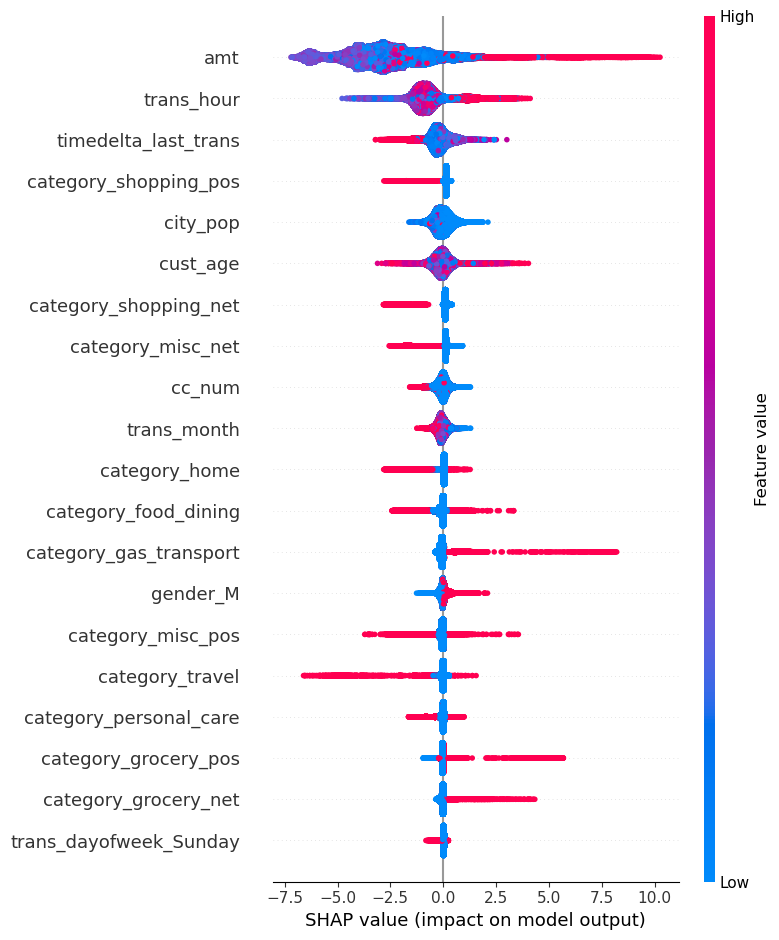

In [25]:
import shap

# Assuming `shap_values` and `explainer` are already computed
shap.summary_plot(shap_values, features=X_val_rfe.toarray(), feature_names=selected_feature_names)


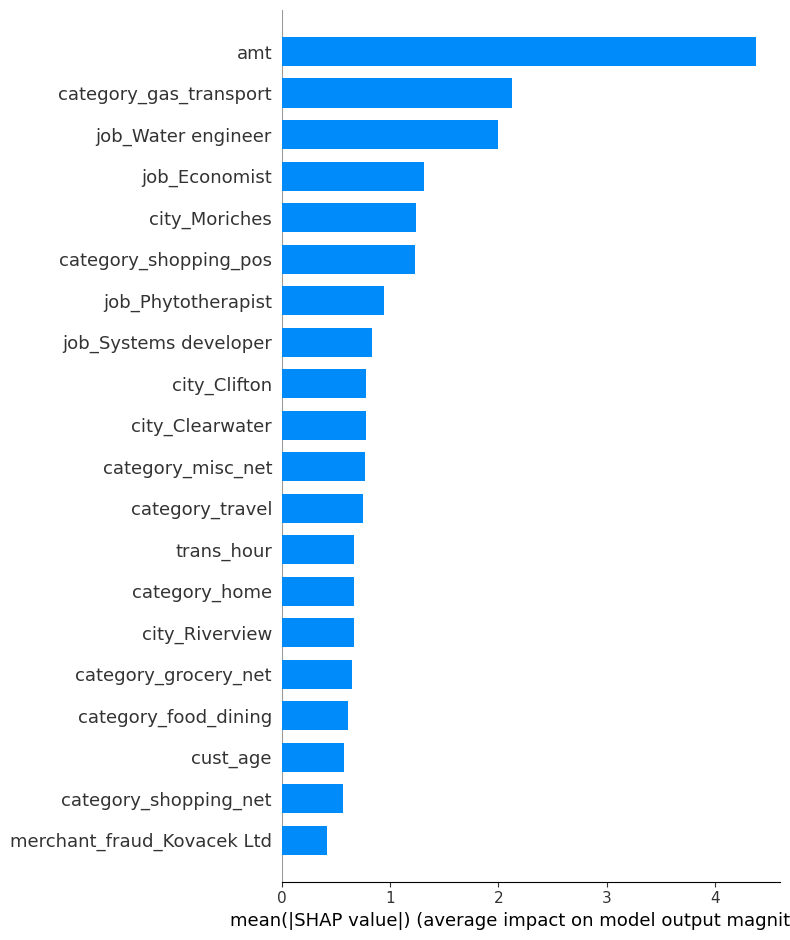

<Figure size 1000x800 with 0 Axes>

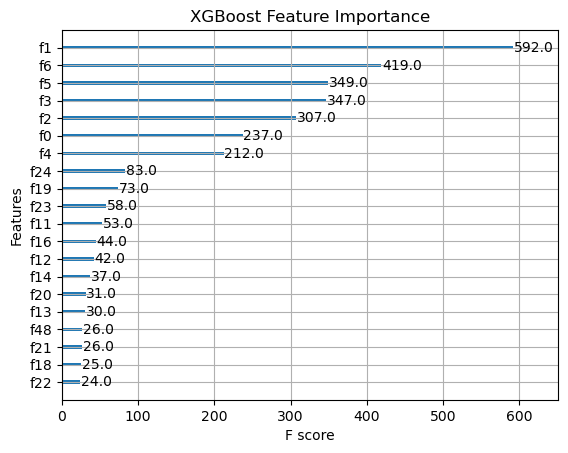

In [26]:
import shap
import numpy as np
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Assuming `X_val_rfe` is a sparse matrix, convert it to dense
X_val_rfe_dense = X_val_rfe.toarray()

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the validation data
shap_values = explainer.shap_values(X_val_rfe_dense)

# Assuming `selected_feature_names` is a list of the RFE-selected feature names
# Summary plot of SHAP values
shap.summary_plot(shap_values, X_val_rfe_dense, feature_names=selected_feature_names, plot_type="bar")

# Feature importance plot using XGBoost's plot_importance function
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=20, importance_type='weight', title='XGBoost Feature Importance')
plt.title("XGBoost Feature Importance")
plt.show()


In [28]:
import shap
import numpy as np
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Load the OneHotEncoder
ohe = joblib.load('onehot_encoder.joblib')

# Get the encoded feature names using the names stored in the OneHotEncoder
encoded_feature_names = ohe.get_feature_names_out()

# Assuming selected_indices is the indices list that you got from RFE
selected_feature_names = [encoded_feature_names[i] for i in selected_indices]

# Ensure X_val_rfe is in dense format
X_val_rfe_dense = X_val_rfe.toarray()

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the validation data
shap_values = explainer.shap_values(X_val_rfe_dense)

# Summary plot of SHAP values
shap.summary_plot(shap_values, X_val_rfe_dense, feature_names=selected_feature_names, plot_type="bar")

# Feature importance plot using XGBoost's plot_importance function
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=20, importance_type='weight', title='XGBoost Feature Importance')
plt.title("XGBoost Feature Importance")
plt.show()


NameError: name 'selected_indices' is not defined